## 📦 Step 1 — Install Required Libraries

In [1]:
# Kaggle already ships TensorFlow, scikit-learn, pandas, numpy, matplotlib, seaborn.
# Only Gradio needs installing for the deployment step (needs Internet = ON in the sidebar).
!pip install -q gradio
print('✅ Environment ready!')

✅ Environment ready!


## 📂 Step 2 — Upload Datasets

In [2]:
import os
import pandas as pd

# List everything that is mounted, then auto-locate the three CSVs.
found = {}
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full = os.path.join(dirname, filename)
        print(full)
        if filename == 'train.csv'       and 'train' not in found: found['train'] = full
        if filename == 'test.csv'        and 'test'  not in found: found['test']  = full
        if filename == 'test_labels.csv' and 'labels' not in found: found['labels'] = full

missing = [k for k in ('train', 'test', 'labels') if k not in found]
if missing:
    raise FileNotFoundError(
        f"Could not find {missing} under /kaggle/input. "
        "Add the 'Jigsaw Toxic Comment Classification Challenge' dataset via '+ Add Input'."
    )

train_df    = pd.read_csv(found['train'])
test_df     = pd.read_csv(found['test'])
test_labels = pd.read_csv(found['labels'])

print(f"\n✅ Loaded train.csv:       {train_df.shape}")
print(f"✅ Loaded test.csv:        {test_df.shape}")
print(f"✅ Loaded test_labels.csv: {test_labels.shape}")

/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/sample_submission.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv

✅ Loaded train.csv:       (159571, 8)
✅ Loaded test.csv:        (153164, 2)
✅ Loaded test_labels.csv: (153164, 7)


## 🔍 Step 3 — Exploratory Data Analysis

=== TRAIN DATA SAMPLE ===
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  

Shape: (159571, 8)


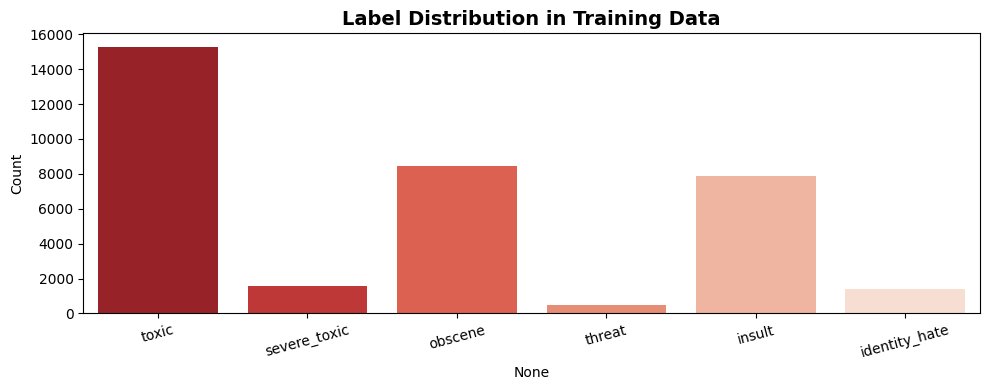


--- Label Percentages ---
  toxic               : 9.58%
  severe_toxic        : 1.00%
  obscene             : 5.29%
  threat              : 0.30%
  insult              : 4.94%
  identity_hate       : 0.88%


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print('=== TRAIN DATA SAMPLE ===')
print(train_df.head(3))
print('\nShape:', train_df.shape)

label_counts = train_df[label_cols].sum()
plt.figure(figsize=(10, 4))
sns.barplot(x=label_counts.index, y=label_counts.values,
            hue=label_counts.index, palette='Reds_r', legend=False)
plt.title('Label Distribution in Training Data', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

total = len(train_df)
print('\n--- Label Percentages ---')
for col in label_cols:
    pct = train_df[col].sum() / total * 100
    print(f'  {col:20s}: {pct:.2f}%')

## 🛠️ Step 4 — Text Preprocessing

In [4]:
import re
import numpy as np

def clean_text(text):
    """Clean and normalize comment text."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

print('Cleaning training text...')
train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
print('Cleaning test text...')
test_df['clean_text'] = test_df['comment_text'].apply(clean_text)

print('✅ Text cleaning complete!')
print('Sample:', train_df['clean_text'].iloc[6])

Cleaning training text...
Cleaning test text...
✅ Text cleaning complete!
Sample: cocksucker before you piss around on my work


## 🔢 Step 5 — Tokenization & Sequence Padding

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

MAX_VOCAB  = 30000   # vocabulary size
MAX_LEN    = 200     # max sequence length (words)

# Fit tokenizer on training data
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

print(f'Vocabulary size: {len(tokenizer.word_index):,}')

# Convert text → sequences → padded arrays
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df[label_cols].values.astype('float32')

print(f'X_train shape: {X_train_pad.shape}')
print(f'X_test  shape: {X_test_pad.shape}')
print(f'y_train shape: {y_train.shape}')

# Save tokenizer for Gradio later
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('💾 Tokenizer saved!')

Vocabulary size: 162,949
X_train shape: (159571, 200)
X_test  shape: (153164, 200)
y_train shape: (159571, 6)
💾 Tokenizer saved!


## 🤖 Step 6 — Build & Train Bidirectional LSTM Model

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense,
    Dropout, GlobalMaxPooling1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU available: {len(gpus) > 0}  ->  {gpus}')
# Allow memory to grow instead of grabbing all VRAM up front.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

EMBED_DIM  = 128
NUM_LABELS = len(label_cols)   # 6

# ── Model Architecture ───────────────────────────────────
# NOTE: recurrent_dropout is intentionally 0. Any non-zero value forces Keras
# off the cuDNN LSTM kernel and onto a generic (10-30x slower) GPU path.
# Regularisation is handled by input `dropout` + Dropout/BatchNorm layers instead.
model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMBED_DIM,
        name='embedding'
    ),

    Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.2),
        name='bilstm_1'
    ),

    Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.2),
        name='bilstm_2'
    ),

    GlobalMaxPooling1D(name='global_max_pool'),

    Dense(128, activation='relu', name='dense_1'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', name='dense_2'),
    Dropout(0.3),

    Dense(NUM_LABELS, activation='sigmoid', name='output')
])

# Build so summary() shows shapes (needed now that input_length is gone).
model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model.summary()

TensorFlow version: 2.20.0
GPU available: True  ->  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1787702869.966550      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 200, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,293,190 (16.38 MB)

 Trainable params: 4,292,934 (16.38 MB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
# ── Train the Model ──────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=3,
        mode='max', restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    )
]

print('🚀 Training Bidirectional LSTM model (cuDNN GPU kernel)...')
history = model.fit(
    X_train_pad, y_train,
    epochs=3,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print('✅ Model training complete!')

# Save in the native Keras 3 format.
model.save('toxic_lstm_model.keras')
print('💾 Model saved as toxic_lstm_model.keras')

🚀 Training Bidirectional LSTM model (cuDNN GPU kernel)...
Epoch 1/3
561/561 ━━━━━━━━━━━━━━━━━━━━ 68s 105ms/step - accuracy: 0.6359 - auc: 0.8731 - loss: 0.0997 - val_accuracy: 0.9939 - val_auc: 0.9481 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 2/3
561/561 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.8615 - auc: 0.9569 - loss: 0.0496 - val_accuracy: 0.9940 - val_auc: 0.9473 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 3/3
561/561 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.8956 - auc: 0.9647 - loss: 0.0442 - val_accuracy: 0.9940 - val_auc: 0.9538 - val_loss: 0.0501 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
✅ Model training complete!
💾 Model saved as toxic_lstm_model.keras


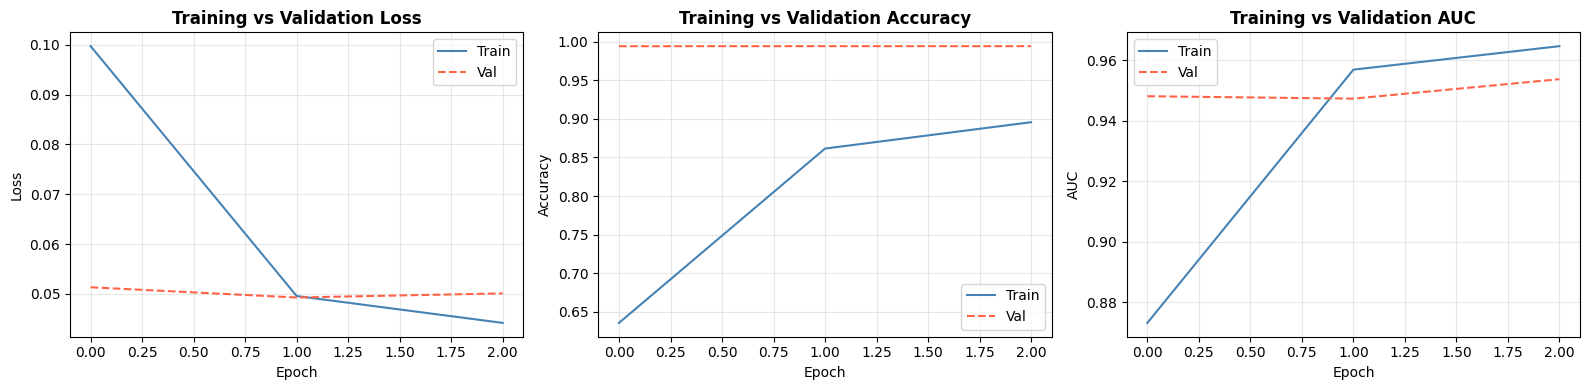

In [8]:
# ── Plot Training History ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'accuracy', 'auc'],
    ['Loss', 'Accuracy', 'AUC']
):
    ax.plot(history.history[metric],       label='Train', color='steelblue')
    ax.plot(history.history[f'val_{metric}'], label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'Training vs Validation {title}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## 📊 Step 7 — Test Model on New Data & Evaluate Performance

In [9]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    hamming_loss, accuracy_score, confusion_matrix
)

# Merge test with labels (drop unlabeled rows where label == -1)
test_merged = test_df.merge(test_labels, on='id')
test_merged = test_merged[test_merged['toxic'] != -1].reset_index(drop=True)

# Re-tokenize the filtered test set
X_test_filtered_seq = tokenizer.texts_to_sequences(test_merged['clean_text'])
X_test_filtered_pad = pad_sequences(X_test_filtered_seq, maxlen=MAX_LEN,
                                    padding='post', truncating='post')
y_test = test_merged[label_cols].values.astype('float32')

print(f'Test samples after filtering: {len(test_merged)}')

# Predict probabilities
print('Running predictions...')
y_pred_proba = model.predict(X_test_filtered_pad, batch_size=512, verbose=1)

# Convert probabilities → binary predictions using 0.5 threshold
y_pred = (y_pred_proba >= 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────
print('\n' + '='*55)
print('           📋 PERFORMANCE METRICS REPORT')
print('='*55)

hl = hamming_loss(y_test, y_pred)
print(f'\n🔸 Hamming Loss         : {hl:.4f}  (lower is better)')

subset_acc = accuracy_score(y_test, y_pred)
print(f'🔸 Exact Match Accuracy : {subset_acc:.4f}')

print('\n🔸 ROC-AUC per label:')
auc_scores = []
for i, col in enumerate(label_cols):
    try:
        auc = roc_auc_score(y_test[:, i], y_pred_proba[:, i])
    except Exception:
        auc = float('nan')
    auc_scores.append(auc)
    print(f'   {col:20s}: {auc:.4f}')

mean_auc = np.nanmean(auc_scores)
print(f'\n🔸 Mean ROC-AUC         : {mean_auc:.4f}')

print('\n🔸 Classification Report (toxic label):')
print(classification_report(y_test[:, 0], y_pred[:, 0],
                             target_names=['Not Toxic', 'Toxic']))

Test samples after filtering: 63978
Running predictions...
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step

           📋 PERFORMANCE METRICS REPORT

🔸 Hamming Loss         : 0.0341  (lower is better)
🔸 Exact Match Accuracy : 0.8597

🔸 ROC-AUC per label:
   toxic               : 0.9600
   severe_toxic        : 0.9869
   obscene             : 0.9758
   threat              : 0.9538
   insult              : 0.9642
   identity_hate       : 0.9434

🔸 Mean ROC-AUC         : 0.9640

🔸 Classification Report (toxic label):
              precision    recall  f1-score   support

   Not Toxic       0.99      0.91      0.95     57888
       Toxic       0.50      0.87      0.64      6090

    accuracy                           0.91     63978
   macro avg       0.74      0.89      0.79     63978
weighted avg       0.94      0.91      0.92     63978



## 📈 Step 8 — Visualize Results

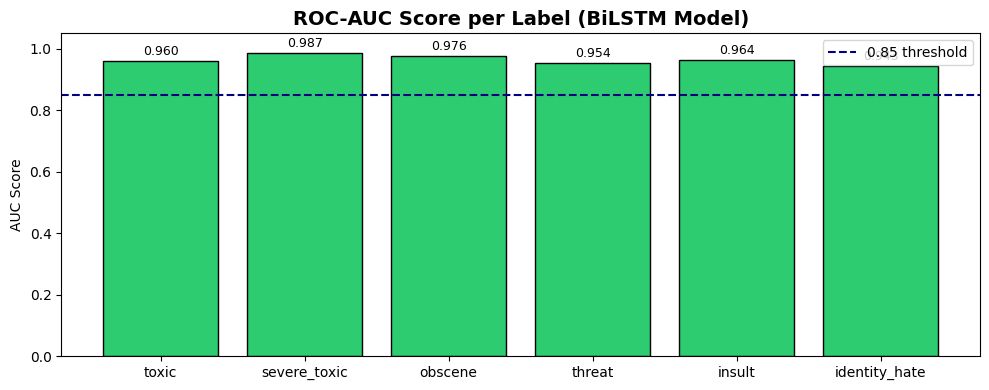

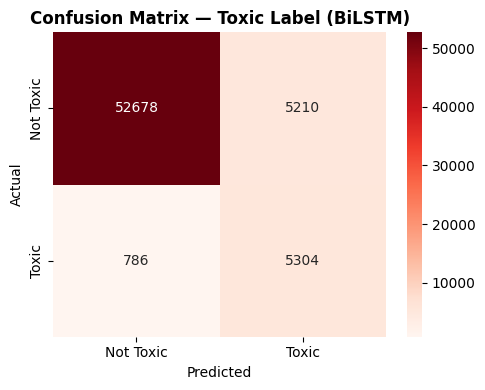


📊 Per-Label Metrics Table:
        Label  Precision   Recall  F1-Score  ROC-AUC
        toxic   0.504470 0.870936  0.638882 0.959953
 severe_toxic   0.315789 0.016349  0.031088 0.986865
      obscene   0.621085 0.762937  0.684742 0.975788
       threat   0.000000 0.000000  0.000000 0.953791
       insult   0.525597 0.674059  0.590642 0.964156
identity_hate   0.000000 0.000000  0.000000 0.943405


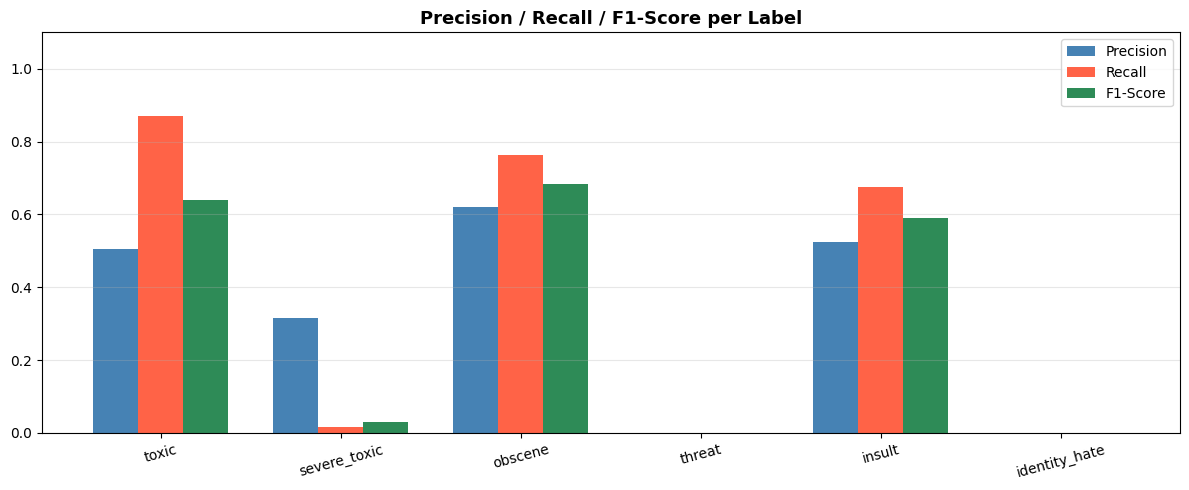

In [10]:
# ── 1. ROC-AUC Bar Chart ─────────────────────────────────
plt.figure(figsize=(10, 4))
colors = ['#e74c3c' if s < 0.85 else '#2ecc71' for s in auc_scores]
bars = plt.bar(label_cols, auc_scores, color=colors, edgecolor='black')
plt.axhline(y=0.85, color='navy', linestyle='--', label='0.85 threshold')
plt.title('ROC-AUC Score per Label (BiLSTM Model)', fontsize=14, fontweight='bold')
plt.ylabel('AUC Score')
plt.ylim(0, 1.05)
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig('roc_auc_chart.png', dpi=150)
plt.show()

# ── 2. Confusion Matrix for 'toxic' label ────────────────
cm = confusion_matrix(y_test[:, 0], y_pred[:, 0])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Toxic', 'Toxic'],
            yticklabels=['Not Toxic', 'Toxic'])
plt.title('Confusion Matrix — Toxic Label (BiLSTM)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 3. Per-label Precision / Recall ──────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_per_label = pd.DataFrame({
    'Label'    : label_cols,
    'Precision': precision_score(y_test, y_pred, average=None, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, average=None, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred, average=None, zero_division=0),
    'ROC-AUC'  : auc_scores
})

print('\n📊 Per-Label Metrics Table:')
print(metrics_per_label.to_string(index=False))

x = np.arange(len(label_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, metrics_per_label['Precision'], width, label='Precision', color='steelblue')
ax.bar(x,         metrics_per_label['Recall'],    width, label='Recall',    color='tomato')
ax.bar(x + width, metrics_per_label['F1-Score'],  width, label='F1-Score',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=15)
ax.set_title('Precision / Recall / F1-Score per Label', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_f1.png', dpi=150)
plt.show()

## 🌐 Step 9 — Deploy as Website using Gradio

In [11]:
import gradio as gr
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load model and tokenizer
lstm_model = load_model('toxic_lstm_model.keras')
with open('tokenizer.pkl', 'rb') as f:
    tok = pickle.load(f)

label_cols  = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
MAX_LEN     = 200

def predict_toxicity(comment: str):
    """Predict toxicity probabilities using BiLSTM model."""
    if not comment or not comment.strip():
        return {label: 0.0 for label in label_cols}

    cleaned  = clean_text(comment)
    seq      = tok.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba    = lstm_model.predict(padded, verbose=0)[0]

    return {
        label.replace('_', ' ').title(): float(round(prob, 4))
        for label, prob in zip(label_cols, proba)
    }

# ── Gradio Interface ─────────────────────────────────────
demo = gr.Interface(
    fn=predict_toxicity,
    inputs=gr.Textbox(
        lines=4,
        placeholder='Type or paste a comment here...',
        label='💬 Comment Text'
    ),
    outputs=gr.Label(
        num_top_classes=6,
        label='🔍 Toxicity Scores'
    ),
    title='☣️ Toxic Comment Classifier (BiLSTM)',
    description=(
        'Deep Learning model (Bidirectional LSTM) trained on the Jigsaw Toxic Comment '
        'Classification dataset. Detects 6 types of toxic content.'
    ),
    examples=[
        ['You are such a wonderful person, keep up the great work!'],
        ['I will kill you if you post that again.'],
        ['This is absolute nonsense and you are an idiot.'],
        ['Thanks for sharing your thoughts, very insightful.'],
        ['You filthy ignorant piece of garbage.'],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=False)
print('\n✅ Gradio app is live! Copy the public URL above for your submission.')

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d3a3a38c05e96a2c08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ Gradio app is live! Copy the public URL above for your submission.


## 💾 Step 10 — Save Results & Download

In [12]:
# On Kaggle, anything written to /kaggle/working appears in the notebook's
# "Output" tab automatically — no google.colab download needed.

# Save predictions
predictions_df = test_merged[['id', 'comment_text']].copy()
for i, col in enumerate(label_cols):
    predictions_df[f'pred_{col}'] = y_pred[:, i]
    predictions_df[f'prob_{col}'] = y_pred_proba[:, i]
predictions_df.to_csv('predictions.csv', index=False)
print('✅ predictions.csv saved!')

# Save metrics summary
metrics_summary = {
    'Model'               : 'Bidirectional LSTM',
    'Hamming Loss'        : hl,
    'Exact Match Accuracy': subset_acc,
    'Mean ROC-AUC'        : mean_auc
}
for col, auc in zip(label_cols, auc_scores):
    metrics_summary[f'AUC_{col}'] = auc

pd.DataFrame([metrics_summary]).to_csv('metrics_summary.csv', index=False)
print('✅ metrics_summary.csv saved!')

# Confirm the output files are present in /kaggle/working
import os
print('\n📂 Files in working directory (downloadable from the Output tab):')
for fname in [
    'predictions.csv', 'metrics_summary.csv',
    'roc_auc_chart.png', 'confusion_matrix.png',
    'precision_recall_f1.png', 'training_history.png',
    'toxic_lstm_model.keras', 'tokenizer.pkl'
]:
    status = '✅' if os.path.exists(fname) else '⚠️  missing'
    print(f'   {status}  {fname}')

✅ predictions.csv saved!
✅ metrics_summary.csv saved!

📂 Files in working directory (downloadable from the Output tab):
   ✅  predictions.csv
   ✅  metrics_summary.csv
   ✅  roc_auc_chart.png
   ✅  confusion_matrix.png
   ✅  precision_recall_f1.png
   ✅  training_history.png
   ✅  toxic_lstm_model.keras
   ✅  tokenizer.pkl


---
## 📝 Summary

| Component | Details |
|---|---|
| **Model** | Bidirectional LSTM (2 layers) + GlobalMaxPooling + Dense |
| **Embedding** | Trainable word embeddings (dim=128, vocab=30k) |
| **Loss** | Binary Crossentropy (multi-label) |
| **Optimizer** | Adam (lr=1e-3) with ReduceLROnPlateau |
| **Sequence Length** | 200 tokens |
| **Labels** | toxic, severe_toxic, obscene, threat, insult, identity_hate |
| **Evaluation** | Hamming Loss · Exact Match Accuracy · ROC-AUC · F1 per label |
| **Deployment** | Gradio web interface with public share link |

> 💡 **Submission checklist:**  
> - [ ] Colab link shared (with all outputs visible)  
> - [ ] Gradio public URL working and tested  
> - [ ] IEEE-format PDF documentation uploaded  
> - [ ] File named with your name and student ID